# Sleep Data Analysis of Mammals

Original dataset: [Kaggle Link](https://www.kaggle.com/datasets/mathurinache/sleep-dataset)

Data from StatLib (ftp stat.cmu.edu/datasets)

Data from which conclusions were drawn in the article "Sleep in Mammals: Ecological and Constitutional Correlates" by Allison, T. and Cicchetti, D. (1976), Science, November 12, vol. 194, pp. 732-734. Includes brain and body weight, life span, gestation time, time sleeping, and predation and danger indices for 62 mammals.

---

Original description
- species of animal
- body weight in kg
- brain weight in g
- slow wave ("nondreaming") sleep (hrs/day)
- paradoxical ("dreaming") sleep (hrs/day)
- total sleep (hrs/day) (sum of slow wave and paradoxical sleep)
- maximum life span (years)
- gestation time [length of pregnancy] (days)
- predation index [how likely an organism is to be preyed upon] (1-5) 1 = minimum (least likely to be preyed upon) 5 = maximum (most likely to be preyed upon)
- sleep exposure index (1-5) 1 = least exposed (e.g. animal sleeps in a well-protected den) 5 = most exposed
- overall danger index (1-5) (based on the above two indices and other information) 1 = least danger (from other animals) 5 = most danger (from other animals)

Note: Missing values denoted by -999.0

---

## 1. Step: Play around with data file and inspect columns

The idea here is to get a feeling for (i) what columns there are, (ii) what datatypes they have, and (iii) which could be useful later on

In [1]:
import pandas as pd

# load file and save to dataframe
df = pd.read_csv("dataset.xls")

In [2]:
# inspect columns + datatypes of columns
# df.columns
df.dtypes

body_weight             float64
brain_weight            float64
max_life_span            object
gestation_time           object
predation_index           int64
sleep_exposure_index      int64
danger_index              int64
total_sleep              object
dtype: object

In [3]:
# show quick statistics
df.describe()

,body_weight,brain_weight,predation_index,sleep_exposure_index,danger_index
count,62.000000,62.000000,62.000000,62.000000,62.000000
mean,198.789984,283.134194,2.870968,2.419355,2.612903
std,899.158011,930.278942,1.476414,1.604792,1.441252
min,0.005000,0.140000,1.000000,1.000000,1.000000
25%,0.600000,4.250000,2.000000,1.000000,1.000000
50%,3.342500,17.250000,3.000000,2.000000,2.000000
75%,48.202500,166.000000,4.000000,4.000000,4.000000
max,6654.000000,5712.000000,5.000000,5.000000,5.000000


In [4]:
# looking at some entries
df.head(20)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645,3,5,3,3.3
1,1.000,6.6,4.5,42,3,1,3,8.3
2,3.385,44.5,14,60,1,1,1,12.5
3,0.920,5.7,?,25,5,2,3,16.5
4,2547.000,4603.0,69,624,3,5,4,3.9
5,10.550,179.5,27,180,4,4,4,9.8
6,0.023,0.3,19,35,1,1,1,19.7
7,160.000,169.0,30.4,392,4,5,4,6.2
8,3.300,25.6,28,63,1,2,1,14.5
9,52.160,440.0,50,230,1,1,1,9.7


# 2. Step: Look for missing data

Usually this would be NaN or missing data, in this case they specified them to be -999.0 (reported, but this is not the case! Missing ones are indicated via '?')

In [5]:
# this alternative df is obtained by just removing Na values
del_na_rows_df = df.copy(deep=True)

# this altenative df is obtained by imputation
imputed_df = df.copy(deep=True)

In [6]:
df.dtypes

body_weight             float64
brain_weight            float64
max_life_span            object
gestation_time           object
predation_index           int64
sleep_exposure_index      int64
danger_index              int64
total_sleep              object
dtype: object

#### Correct datatypes:
- body_weight
- brain_weight
- predation_index
- sleep_exposure_index
- danger_index

-> only look for outliers maybe?

#### Incorrect datatypes:
- max_life_span -> should be float?
- gestation_time -> should be float/int?
- total_sleep -> should be float?

-> check for missing values and impute maybe?

### 1. Solution: just remove rows with missing values

This leads to loosing information, but serves as simple baseline.

In [7]:
# first imputation: just remove Na values
del_na_rows_df.max_life_span = pd.to_numeric(del_na_rows_df.max_life_span, errors='coerce')
del_na_rows_df.gestation_time = pd.to_numeric(del_na_rows_df.gestation_time, errors='coerce')
del_na_rows_df.total_sleep = pd.to_numeric(del_na_rows_df.total_sleep, errors='coerce')

In [8]:
# check how many values are missing in each column
del_na_rows_df.isna().sum()

body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             4
dtype: int64

In [9]:
# remove na values
del_na_rows_df = del_na_rows_df.dropna()

# check how many entries remain
remaining = len(del_na_rows_df)
original = len(df)
print(f"Removing na values lead to loosing {original - remaining} rows. Therefore, exactly {remaining} rows remain")


Removing na values lead to loosing 11 rows. Therefore, exactly 51 rows remain


### 2. Solution: perform imputation

Using imputation, we can keep a larger portion of the original data. The motivation behind this is also to introduce a weaker bias since removing na value rows introduces a strong bias.

In [10]:
# TODO: perform mean, or other more sophisticated imputation

# 3. Step: Perform Analyses

We perform the analysis on the differently imputed datasets. Maybe we can thereby also see how this leads to different results, showcasing the bias introduced by removing na valued rows.

## (a) with removed na values df

array([[<Axes: xlabel='body_weight', ylabel='body_weight'>,
        <Axes: xlabel='brain_weight', ylabel='body_weight'>,
        <Axes: xlabel='max_life_span', ylabel='body_weight'>,
        <Axes: xlabel='gestation_time', ylabel='body_weight'>,
        <Axes: xlabel='predation_index', ylabel='body_weight'>,
        <Axes: xlabel='sleep_exposure_index', ylabel='body_weight'>,
        <Axes: xlabel='danger_index', ylabel='body_weight'>,
        <Axes: xlabel='total_sleep', ylabel='body_weight'>],
       [<Axes: xlabel='body_weight', ylabel='brain_weight'>,
        <Axes: xlabel='brain_weight', ylabel='brain_weight'>,
        <Axes: xlabel='max_life_span', ylabel='brain_weight'>,
        <Axes: xlabel='gestation_time', ylabel='brain_weight'>,
        <Axes: xlabel='predation_index', ylabel='brain_weight'>,
        <Axes: xlabel='sleep_exposure_index', ylabel='brain_weight'>,
        <Axes: xlabel='danger_index', ylabel='brain_weight'>,
        <Axes: xlabel='total_sleep', ylabel='brain_w

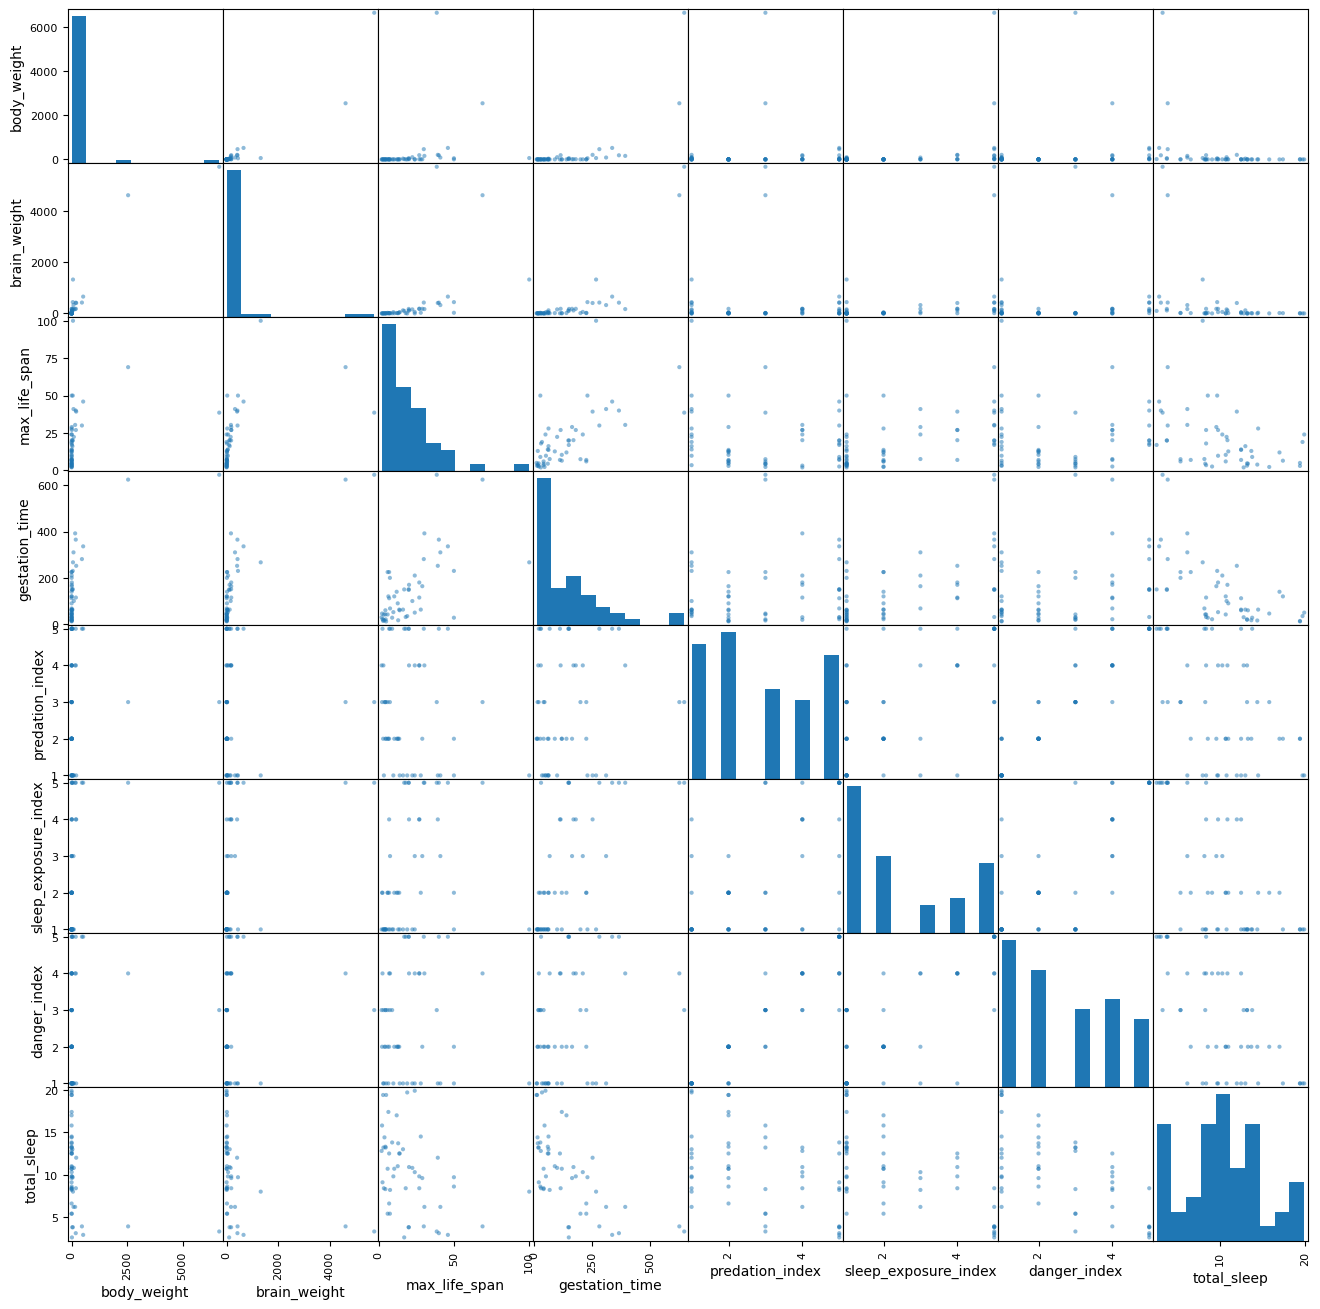

In [11]:
# look at correlation/scatter plot matrix--this tells us what features are descriptive of what other features
pd.plotting.scatter_matrix(del_na_rows_df, figsize=(16,16))

In [34]:
# Idea/Exercise 1: a tiger only knows some X features of the dataset table and wants to predict some feature Y. For example a tiger only knows all features except how exposed an animal is during it's sleep and wants to estimate that such that it can find the animal sleeping during the night. However, since all animals start sleeping at the same time, the tiger can only focus on animals that do not wake up earlier than the tiger. The tiger sleeps about 5 hours


# first filter for animals that sleep longer than 5 hours:
curr_df = del_na_rows_df[del_na_rows_df['total_sleep'] >= 5]

# then split the dataframe into features and target column
X = curr_df[['body_weight', 'brain_weight', 'max_life_span', 'gestation_time', 'predation_index', 'danger_index', 'total_sleep']]
y = curr_df['sleep_exposure_index']

# now split this into train and test dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# perform scaling to make all features equally important
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train = X_train_scaled
X_test = X_test_scaled

# Now we perform linear regression of the features to the target feature which is how exposed an animal sleeps, this lets the tiger assess whether or not it can find that animal unprotected.
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)


# evaluate prediction
from sklearn.metrics import r2_score  
y_pred = regressor.predict(X_test)  

r2 = r2_score(y_test, y_pred)  
print(f"R-squared: {r2}")

R-squared: 0.5249682218770967


The performance is arguably bad, we now compare it to the dummy variant:

In [36]:
from sklearn.dummy import DummyRegressor

# perform dummy regression
regressor = DummyRegressor()
regressor.fit(X_train, y_train)

# evaluate prediction
from sklearn.metrics import r2_score  
y_pred = regressor.predict(X_test)  

r2 = r2_score(y_test, y_pred)  
print(f"R-squared: {r2}")

R-squared: -0.00746268656716409


This tells us that our linear regression is better than random guessing / just predicting the mean but it doesn't give a good estimate for all features either. Let's inspect the correlations:

In [43]:
curr_df.corr(method='pearson')

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
body_weight,1.000000,0.454439,0.458337,0.554036,-0.102344,0.448259,-0.015425,-0.273136
brain_weight,0.454439,1.000000,0.883336,0.541506,-0.276500,0.069305,-0.219368,-0.270535
max_life_span,0.458337,0.883336,1.000000,0.539853,-0.322927,0.191901,-0.208110,-0.266329
gestation_time,0.554036,0.541506,0.539853,1.000000,-0.073014,0.480520,0.077180,-0.536084
predation_index,-0.102344,-0.276500,-0.322927,-0.073014,1.000000,0.476350,0.931621,-0.225675
sleep_exposure_index,0.448259,0.069305,0.191901,0.480520,0.476350,1.000000,0.621383,-0.395377
danger_index,-0.015425,-0.219368,-0.208110,0.077180,0.931621,0.621383,1.000000,-0.411972
total_sleep,-0.273136,-0.270535,-0.266329,-0.536084,-0.225675,-0.395377,-0.411972,1.000000


We can see that none of the features used for the correlation have a strong(er) correlation with the `sleep_exposure_index`. Only `danger_index` has a mild correlation of `0.62` -- this explains why our linear regression does work too well. Furthermore, the dataset is very small and the model cannot learn a lot.

Actual correlations that we can see are between `danger_index` and `predation_index`. And between `brain_weight` and `max_life_span`.